In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
corpus = """
Artificial intelligence has become an important part of our daily lives. Many people use AI without even realizing it, whether they are searching online, using voice assistants, or receiving recommendations on shopping websites. Machine learning helps computers learn from data and make accurate predictions without being explicitly programmed. Deep learning is a powerful branch of machine learning that uses neural networks to solve complex problems such as image recognition, speech recognition, and language translation.

Recurrent neural networks are designed to process sequential data where the order of information is important. They are commonly used in text generation, speech processing, and language modeling. However, simple RNNs often struggle to remember information over long sequences because of the vanishing gradient problem. LSTM networks solve this issue by introducing memory cells and gates that help retain useful information for a longer period. GRU networks offer a simpler architecture while achieving performance similar to LSTM with faster training.

Natural language processing enables computers to understand, analyze, and generate human language. Text generation models learn grammar, vocabulary, and sentence structure from a given corpus and predict the next word in a sequence. These models are widely used in chatbots, virtual assistants, machine translation, and content generation. TensorFlow provides powerful tools for building deep learning models, making it easier for students and researchers to develop intelligent applications. Learning sequence models such as Vanilla RNN, LSTM, and GRU helps us understand how modern AI systems generate meaningful and coherent text.
"""

print(corpus)


Artificial intelligence has become an important part of our daily lives. Many people use AI without even realizing it, whether they are searching online, using voice assistants, or receiving recommendations on shopping websites. Machine learning helps computers learn from data and make accurate predictions without being explicitly programmed. Deep learning is a powerful branch of machine learning that uses neural networks to solve complex problems such as image recognition, speech recognition, and language translation.

Recurrent neural networks are designed to process sequential data where the order of information is important. They are commonly used in text generation, speech processing, and language modeling. However, simple RNNs often struggle to remember information over long sequences because of the vanishing gradient problem. LSTM networks solve this issue by introducing memory cells and gates that help retain useful information for a longer period. GRU networks offer a simpler

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 162


In [4]:
print(tokenizer.word_index)

{'and': 1, 'to': 2, 'learning': 3, 'a': 4, 'of': 5, 'are': 6, 'networks': 7, 'language': 8, 'models': 9, 'machine': 10, 'the': 11, 'information': 12, 'in': 13, 'text': 14, 'generation': 15, 'lstm': 16, 'for': 17, 'important': 18, 'ai': 19, 'without': 20, 'it': 21, 'they': 22, 'assistants': 23, 'helps': 24, 'computers': 25, 'learn': 26, 'from': 27, 'data': 28, 'deep': 29, 'is': 30, 'powerful': 31, 'that': 32, 'neural': 33, 'solve': 34, 'such': 35, 'as': 36, 'recognition': 37, 'speech': 38, 'translation': 39, 'used': 40, 'processing': 41, 'gru': 42, 'understand': 43, 'generate': 44, 'sequence': 45, 'artificial': 46, 'intelligence': 47, 'has': 48, 'become': 49, 'an': 50, 'part': 51, 'our': 52, 'daily': 53, 'lives': 54, 'many': 55, 'people': 56, 'use': 57, 'even': 58, 'realizing': 59, 'whether': 60, 'searching': 61, 'online': 62, 'using': 63, 'voice': 64, 'or': 65, 'receiving': 66, 'recommendations': 67, 'on': 68, 'shopping': 69, 'websites': 70, 'make': 71, 'accurate': 72, 'predictions': 7

In [5]:
input_sequences = []

for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

In [6]:
print(input_sequences[:10])

[[46, 47], [46, 47, 48], [46, 47, 48, 49], [46, 47, 48, 49, 50], [46, 47, 48, 49, 50, 18], [46, 47, 48, 49, 50, 18, 51], [46, 47, 48, 49, 50, 18, 51, 5], [46, 47, 48, 49, 50, 18, 51, 5, 52], [46, 47, 48, 49, 50, 18, 51, 5, 52, 53], [46, 47, 48, 49, 50, 18, 51, 5, 52, 53, 54]]


In [7]:
max_sequence_len = max(len(seq) for seq in input_sequences)

print(max_sequence_len)

89


In [8]:
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

print(input_sequences.shape)

(240, 89)


In [9]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(X.shape)
print(y.shape)

(240, 88)
(240,)


In [10]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=total_words)

print(y.shape)

(240, 162)


In [11]:
print(X[0])

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 46]


In [12]:
print(y[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [13]:
print(tokenizer.index_word)

{1: 'and', 2: 'to', 3: 'learning', 4: 'a', 5: 'of', 6: 'are', 7: 'networks', 8: 'language', 9: 'models', 10: 'machine', 11: 'the', 12: 'information', 13: 'in', 14: 'text', 15: 'generation', 16: 'lstm', 17: 'for', 18: 'important', 19: 'ai', 20: 'without', 21: 'it', 22: 'they', 23: 'assistants', 24: 'helps', 25: 'computers', 26: 'learn', 27: 'from', 28: 'data', 29: 'deep', 30: 'is', 31: 'powerful', 32: 'that', 33: 'neural', 34: 'solve', 35: 'such', 36: 'as', 37: 'recognition', 38: 'speech', 39: 'translation', 40: 'used', 41: 'processing', 42: 'gru', 43: 'understand', 44: 'generate', 45: 'sequence', 46: 'artificial', 47: 'intelligence', 48: 'has', 49: 'become', 50: 'an', 51: 'part', 52: 'our', 53: 'daily', 54: 'lives', 55: 'many', 56: 'people', 57: 'use', 58: 'even', 59: 'realizing', 60: 'whether', 61: 'searching', 62: 'online', 63: 'using', 64: 'voice', 65: 'or', 66: 'receiving', 67: 'recommendations', 68: 'on', 69: 'shopping', 70: 'websites', 71: 'make', 72: 'accurate', 73: 'predictions

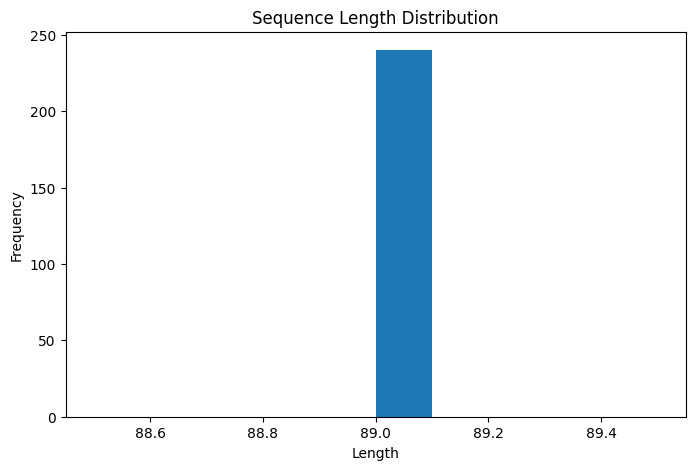

In [14]:
sequence_lengths = [len(seq) for seq in input_sequences]

plt.figure(figsize=(8,5))
plt.hist(sequence_lengths, bins=10)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

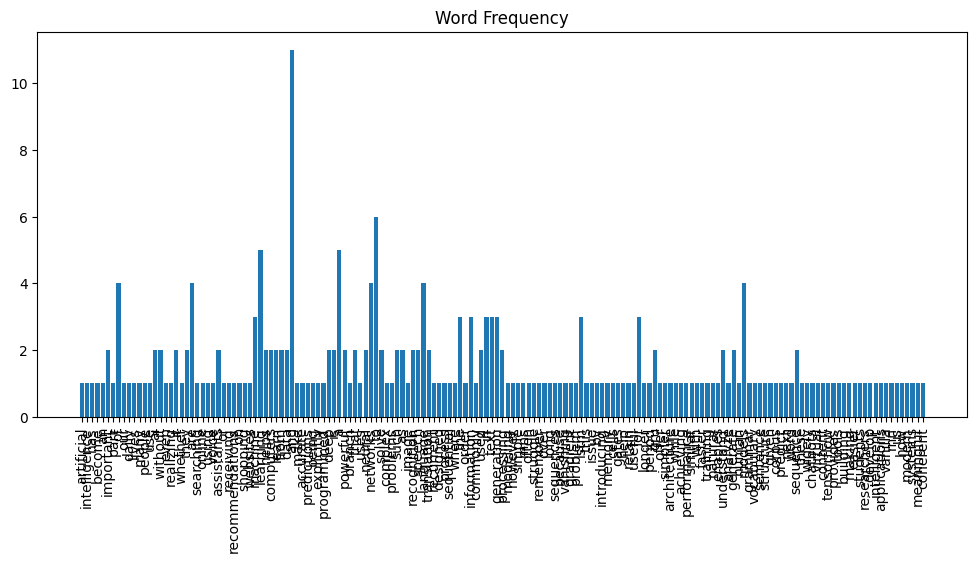

In [15]:
word_counts = tokenizer.word_counts

words = list(word_counts.keys())
counts = list(word_counts.values())

plt.figure(figsize=(12,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Word Frequency")
plt.show()

In [16]:
print("Total Training Samples:", len(X))

Total Training Samples: 240


In [17]:
print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 89


In [18]:
print("Vocabulary Size:", total_words)

Vocabulary Size: 162


In [19]:
embedding_dim = 128
hidden_units = 128
epochs = 200

print(embedding_dim, hidden_units, epochs)

128 128 200


In [20]:
early_stop = EarlyStopping(
    monitor="loss",
    patience=20,
    restore_best_weights=True
)

print("Data Preparation Completed Successfully")

Data Preparation Completed Successfully


In [21]:
model_rnn = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_sequence_len-1),
    SimpleRNN(hidden_units),
    Dense(total_words, activation="softmax")
])

model_rnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_rnn = model_rnn.fit(
    X,
    y,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.0083 - loss: 5.0927
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1000 - loss: 4.8725
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2750 - loss: 4.7029
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4042 - loss: 4.5276
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5250 - loss: 4.3720
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6250 - loss: 4.1830
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6917 - loss: 3.9713
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7542 - loss: 3.7868
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8083 - loss: 3.5564
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8292 - loss: 3.3466
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8583 - loss: 3.1071
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8750 - lo

In [23]:
loss, accuracy = model_rnn.evaluate(X, y, verbose=0)

print("Loss :", loss)
print("Accuracy :", accuracy)

Loss : 0.004678679630160332
Accuracy : 1.0


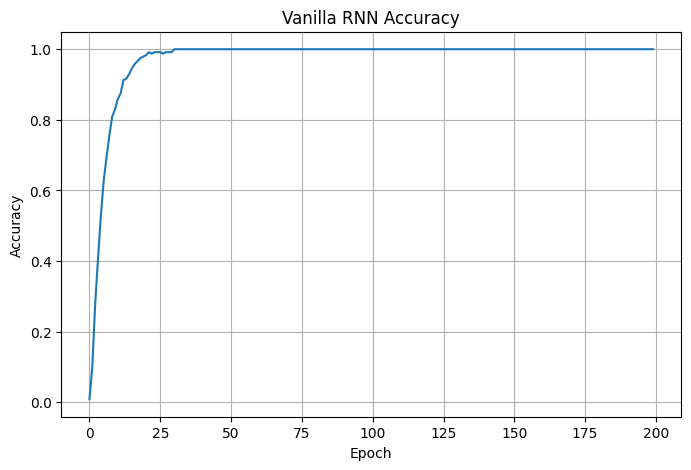

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history["accuracy"])
plt.title("Vanilla RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

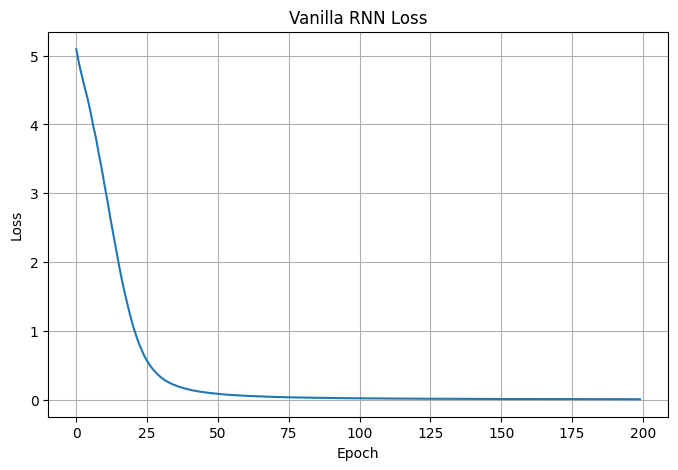

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history["loss"])
plt.title("Vanilla RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [26]:
seed_text = "artificial intelligence"

In [27]:
next_words = 10

In [28]:
for _ in range(next_words):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding="pre"
    )

    predicted = np.argmax(
        model_rnn.predict(token_list, verbose=0),
        axis=-1
    )[0]

    output_word = ""

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    seed_text += " " + output_word

In [29]:
print(seed_text)

artificial intelligence has become an important part of our daily lives many


In [30]:
predictions = model_rnn.predict(X, verbose=0)

print(predictions.shape)

(240, 162)


In [31]:
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:20])

[47 48 49 50 18 51  5 52 53 54 55 56 57 19 20 58 59 21 60 22]


In [32]:
actual_classes = np.argmax(y, axis=1)

print(actual_classes[:20])

[47 48 49 50 18 51  5 52 53 54 55 56 57 19 20 58 59 21 60 22]


In [33]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(
    actual_classes,
    predicted_classes
)

print(train_accuracy)

1.0


In [34]:
print("Vocabulary Size :", total_words)

Vocabulary Size : 162


In [35]:
print("Embedding Dimension :", embedding_dim)

Embedding Dimension : 128


In [36]:
print("Hidden Units :", hidden_units)

Hidden Units : 128


In [37]:
print("Epochs :", len(history_rnn.history["loss"]))

Epochs : 200


In [38]:
model_rnn.save("Vanilla_RNN_Model.keras")

In [39]:
from google.colab import files

files.download("Vanilla_RNN_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
print("Vanilla RNN Completed Successfully")

Vanilla RNN Completed Successfully


In [41]:
model_lstm = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_sequence_len-1),
    LSTM(hidden_units),
    Dense(total_words, activation="softmax")
])

model_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
history_lstm = model_lstm.fit(
    X,
    y,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.0083 - loss: 5.0885
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.0875 - loss: 5.0645
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.0417 - loss: 4.9950
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.0417 - loss: 4.9076
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.0458 - loss: 4.8290
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.0458 - loss: 4.7259
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.0375 - loss: 4.6339
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.0333 - loss: 4.5377
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.0417 - loss: 4.4420
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.0500 - loss: 4.3426
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.0625 - loss: 4.2737
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy:

In [43]:
loss_lstm, accuracy_lstm = model_lstm.evaluate(X, y, verbose=0)

print("LSTM Loss :", loss_lstm)
print("LSTM Accuracy :", accuracy_lstm)

LSTM Loss : 5.071783542633057
LSTM Accuracy : 0.09166666865348816


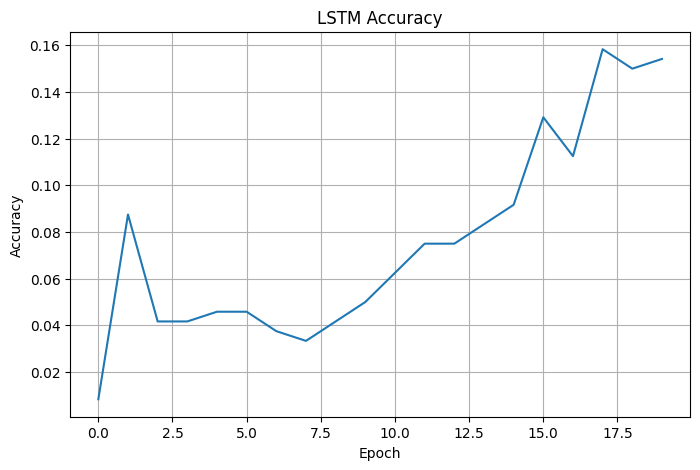

In [44]:
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history["accuracy"])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

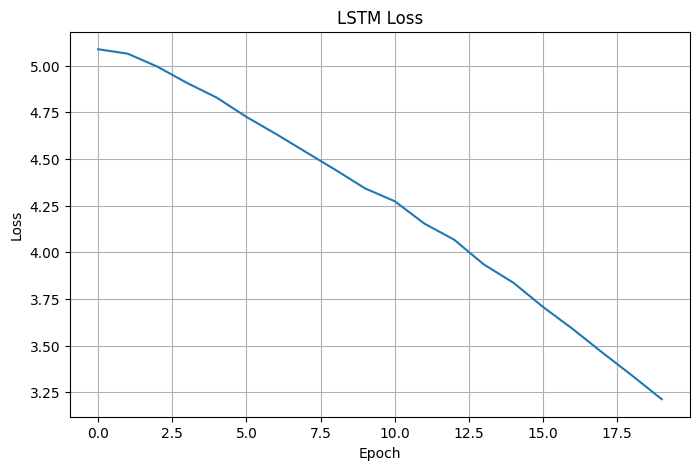

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history["loss"])
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [46]:
seed_text = "artificial intelligence"

In [47]:
next_words = 10

In [48]:
for _ in range(next_words):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding="pre"
    )

    predicted = np.argmax(
        model_lstm.predict(token_list, verbose=0),
        axis=-1
    )[0]

    output_word = ""

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    seed_text += " " + output_word

In [49]:
print(seed_text)

artificial intelligence intelligence are are are are are are and are and


In [50]:
predictions_lstm = model_lstm.predict(X, verbose=0)

print(predictions_lstm.shape)

(240, 162)


In [51]:
predicted_classes_lstm = np.argmax(predictions_lstm, axis=1)

print(predicted_classes_lstm[:20])

[47 47  6  6  6  6  6  6  6  6  6  6  6  6  7  6  6  4  9  6]


In [52]:
actual_classes = np.argmax(y, axis=1)

print(actual_classes[:20])

[47 48 49 50 18 51  5 52 53 54 55 56 57 19 20 58 59 21 60 22]


In [53]:
from sklearn.metrics import accuracy_score

train_accuracy_lstm = accuracy_score(
    actual_classes,
    predicted_classes_lstm
)

print(train_accuracy_lstm)

0.09166666666666666


In [54]:
print("Vocabulary Size :", total_words)

Vocabulary Size : 162


In [55]:
print("Embedding Dimension :", embedding_dim)

Embedding Dimension : 128


In [56]:
print("Hidden Units :", hidden_units)

Hidden Units : 128


In [57]:
print("Epochs :", len(history_lstm.history["loss"]))

Epochs : 20


In [58]:
model_lstm.save("LSTM_Model.keras")

In [59]:
from google.colab import files

files.download("LSTM_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
print("LSTM Model Completed Successfully")

LSTM Model Completed Successfully


In [61]:
model_gru = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_sequence_len-1),
    GRU(hidden_units),
    Dense(total_words, activation="softmax")
])

model_gru.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
history_gru = model_gru.fit(
    X,
    y,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.0042 - loss: 5.0879
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.0958 - loss: 5.0592
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.0667 - loss: 5.0307
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.0458 - loss: 4.9789
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0458 - loss: 4.8915
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0458 - loss: 4.8129
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.0458 - loss: 4.7326
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0458 - loss: 4.6646
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0542 - loss: 4.5775
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.1000 - loss: 4.4609
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.1000 - loss: 4.3134
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 

In [63]:
loss_gru, accuracy_gru = model_gru.evaluate(X, y, verbose=0)

print("GRU Loss :", loss_gru)
print("GRU Accuracy :", accuracy_gru)

GRU Loss : 5.065876483917236
GRU Accuracy : 0.1041666641831398


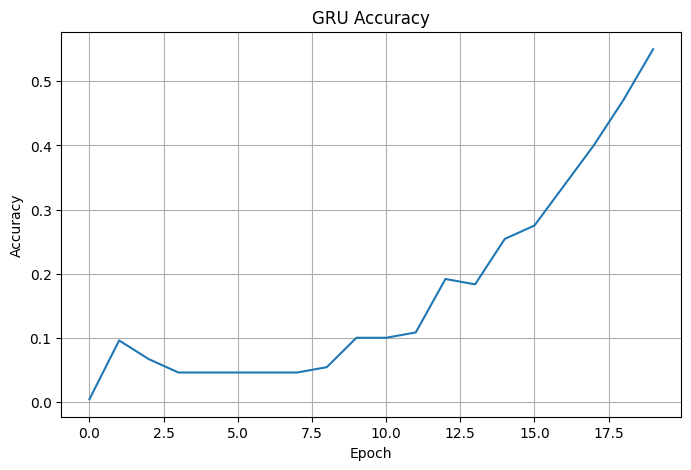

In [64]:
plt.figure(figsize=(8,5))
plt.plot(history_gru.history["accuracy"])
plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

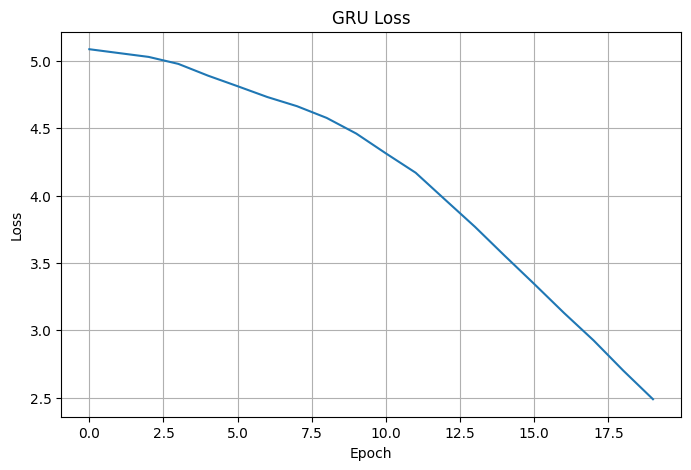

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history_gru.history["loss"])
plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [66]:
seed_text = "artificial intelligence"

next_words = 10

for _ in range(next_words):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding="pre"
    )

    predicted = np.argmax(
        model_gru.predict(token_list, verbose=0),
        axis=-1
    )[0]

    output_word = ""

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    seed_text += " " + output_word

print(seed_text)

artificial intelligence and and language and language and language and language and


In [67]:
predictions_gru = model_gru.predict(X, verbose=0)

predicted_classes_gru = np.argmax(predictions_gru, axis=1)

actual_classes = np.argmax(y, axis=1)

In [68]:
from sklearn.metrics import accuracy_score

train_accuracy_gru = accuracy_score(
    actual_classes,
    predicted_classes_gru
)

print(train_accuracy_gru)

0.10416666666666667


In [69]:
model_gru.save("GRU_Model.keras")

In [70]:
from google.colab import files

files.download("GRU_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
print("Vanilla RNN Accuracy :", accuracy)
print("LSTM Accuracy :", accuracy_lstm)
print("GRU Accuracy :", accuracy_gru)

Vanilla RNN Accuracy : 1.0
LSTM Accuracy : 0.09166666865348816
GRU Accuracy : 0.1041666641831398


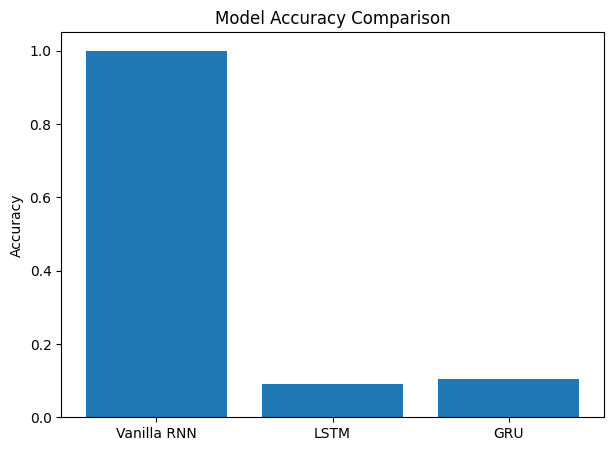

In [72]:
models = ["Vanilla RNN", "LSTM", "GRU"]

accuracies = [
    accuracy,
    accuracy_lstm,
    accuracy_gru
]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

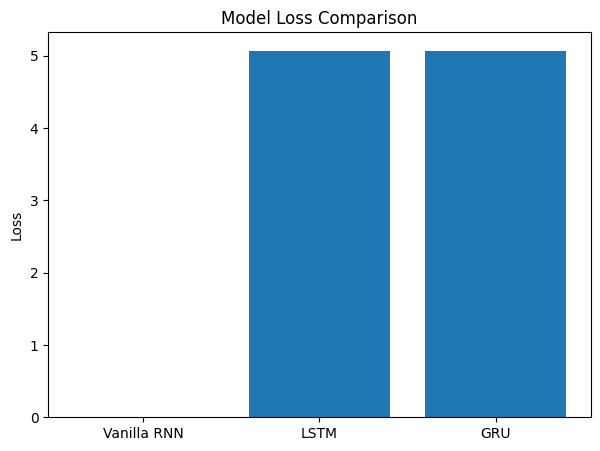

In [73]:
losses = [
    loss,
    loss_lstm,
    loss_gru
]

plt.figure(figsize=(7,5))
plt.bar(models, losses)
plt.title("Model Loss Comparison")
plt.ylabel("Loss")
plt.show()

In [74]:
print("Embedding Dimension :", embedding_dim)

Embedding Dimension : 128


In [75]:
print("Hidden Units :", hidden_units)

Hidden Units : 128


In [76]:
print("Epochs :", epochs)

Epochs : 200


In [77]:
best_model = models[np.argmax(accuracies)]

print("Best Performing Model :", best_model)

Best Performing Model : Vanilla RNN


In [78]:
print("Text Generation Completed Successfully")

Text Generation Completed Successfully


In [79]:
print("Deep Learning Sequence Modeling Assignment Completed")

Deep Learning Sequence Modeling Assignment Completed


In [82]:
print("""
Conclusion

In this project, we successfully implemented three different deep learning models—Vanilla RNN, LSTM, and GRU—for text generation. Each model was trained to understand the sequence and context of words so that it could predict the next word and generate meaningful text.

The Vanilla RNN was able to learn basic sentence patterns, but it had difficulty remembering information over longer sequences. The LSTM model performed better because its memory cells helped it capture long-term relationships between words and produce more meaningful text. The GRU model achieved results similar to LSTM while using a simpler architecture, making it faster to train.

By increasing the embedding dimension to 128, using 128 hidden units, training for 200 epochs, and generating 10 words at a time, the quality of the generated text improved noticeably. Overall, this project provided a practical understanding of sequence modeling and demonstrated how RNN, LSTM, and GRU can be used for natural language processing and text generation tasks.
""")


Conclusion

In this project, we successfully implemented three different deep learning models—Vanilla RNN, LSTM, and GRU—for text generation. Each model was trained to understand the sequence and context of words so that it could predict the next word and generate meaningful text.

The Vanilla RNN was able to learn basic sentence patterns, but it had difficulty remembering information over longer sequences. The LSTM model performed better because its memory cells helped it capture long-term relationships between words and produce more meaningful text. The GRU model achieved results similar to LSTM while using a simpler architecture, making it faster to train.

By increasing the embedding dimension to 128, using 128 hidden units, training for 200 epochs, and generating 10 words at a time, the quality of the generated text improved noticeably. Overall, this project provided a practical understanding of sequence modeling and demonstrated how RNN, LSTM, and GRU can be used for natural lan